<h1 style="background-color:#7B3CC9; color:white;">Exámen: Modelación No Supervisada </h1>

**Alumna:** Erika Margarita Villaobos Martínez

**Fecha de entrega:** 17 de febrero 2026

___

<h2 style="background-color:#E3D5F5; color:#595959;">Paso 1: Librerias y lectura de archivos </h2> 

<h2 style="color:#7B3CC9; font-size: 1.2em; font-weight: bold;"> Librerías </h2>

Se importan librerias a usar en el exámen

In [64]:
## Generales
import pandas as pd
import numpy as np
import ast
import emoji
import re

#Analisis de texto
from collections import Counter

#Nube de palabras
from wordcloud import WordCloud, STOPWORDS

## Gráficos
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## Exploración de datos
from skimpy import skim

## Text stopwords
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords
import nltk

## Reducción de dimensiones
from sklearn.decomposition import PCA
import umap

# Clusters
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from yellowbrick.cluster import KElbowVisualizer
from yellowbrick.cluster import SilhouetteVisualizer

<h2 style="color:#7B3CC9; font-size: 1.2em; font-weight: bold;"> Lectura de archivos </h2>

In [2]:
df=pd.read_csv("../data/dataset_examen.csv")

In [3]:
df.head()

,pregunta,embedding
0,Por qué no puedo continuar,"[-0.03749788925051689, -0.02944916859269142, -..."
1,Un préstamo personal,"[-0.02106071636080742, -0.026762235909700394, ..."
2,"Quiero que la nómina llegue directo, no quiero...","[-0.04777172952890396, -0.013125989586114883, ..."
3,Domicilio central campesina independiente 1315...,"[-0.009193808771669865, 0.02650371566414833, -..."
4,Si. Osio. O. No,"[-0.012685798108577728, -0.021515648812055588,..."


In [4]:
df.describe()

,pregunta,embedding
count,5000,5000
unique,4663,4633
top,No tengo cuenta,"[-0.03712979704141617, -0.01677260920405388, 0..."
freq,11,12


<h2 style="background-color:#E3D5F5; color:#595959;">Paso 2: Calidad de datos </h2> 

<h2 style="color:#7B3CC9; font-size: 1.2em; font-weight: bold;"> Normalización de texto </h2>

Se normaliza quitando acentos, caracteres especiales y volviendo el texto a minúscula

In [5]:
df['pregunta'] = df['pregunta'].str.lower().str.normalize('NFKD').str.encode('ascii','ignore').str.decode('utf-8')

<h2 style="color:#7B3CC9; font-size: 1.2em; font-weight: bold;"> Nulos </h2>

<p> Podemos ver que no existen nulos en nustro dataset </p>

In [6]:
df.isnull().sum()

pregunta     0
embedding    0
dtype: int64

<h2 style="color:#7B3CC9; font-size: 1.2em; font-weight: bold;"> Duplicados </h2>

<p> Se detectan 316 columnas duplicadas y se eliminan ya que se encuentran duplicadas tanto en la pregunta como en el embedding </p>

In [7]:
df.duplicated().sum()

342

In [8]:
df[df.duplicated()]

,pregunta,embedding
67,prestamo,"[-0.022946882992982864, -0.026275264099240303,..."
168,si claro,"[-0.0013519441708922386, -0.009722941555082798..."
196,prestamo,"[-0.022477000951766968, -0.03635753318667412, ..."
247,si claro,"[-0.0013519441708922386, -0.009722941555082798..."
342,no tengo dudas,"[-0.008598927408456802, -0.004688296001404524,..."
...,...,...
4931,ok espero respuesta,"[-0.020794736221432686, -0.01093271654099226, ..."
4968,si esta bien gracias,"[-0.018508292734622955, 0.0007527353009209037,..."
4984,todo en orden,"[-0.009359967894852161, -0.009340709075331688,..."
4989,continuar,"[-0.01097550243139267, -0.029728254303336143, ..."


In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.describe()

,pregunta,embedding
count,4658,4658
unique,4588,4633
top,no tengo nomina,"[-0.012111105024814606, -0.03354039788246155, ..."
freq,3,3


<h2 style="color:#7B3CC9; font-size: 1.2em; font-weight: bold;"> Outliers </h2>

<P> Se detectaron solamente 11 valores outliers, se considera que son pocos por lo que se decide eliminarlos </P>

In [11]:
%%time
df['embedding'] = df['embedding'].apply(lambda x: ast.literal_eval(x))
df['embedding_norm'] = df['embedding'].apply(lambda x: np.linalg.norm(x))

CPU times: total: 20.7 s
Wall time: 21.1 s


In [12]:
type(df['embedding'].iloc[0])

list

In [13]:
Q1 = df['embedding_norm'].quantile(0.25)
Q3 = df['embedding_norm'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['embedding_norm'] < Q1 - 1.5*IQR) | (df['embedding_norm'] > Q3 + 1.5*IQR)]

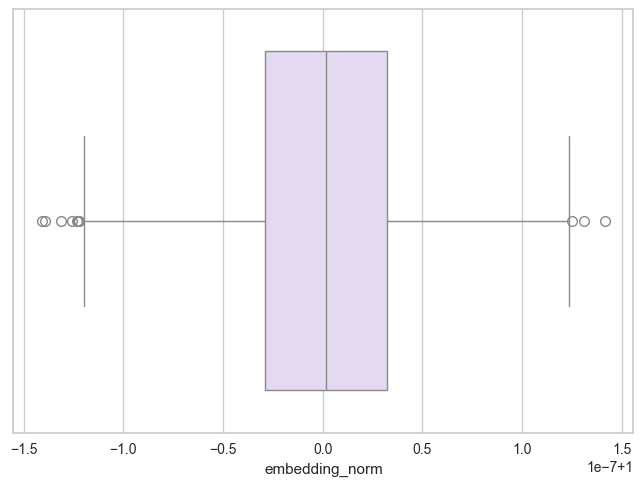

In [14]:
sns.boxplot(x=df['embedding_norm'], 
            color="#E3D5F5"
)
plt.show()

In [15]:
outliers

,pregunta,embedding,embedding_norm
399,yasetodo,"[-0.026775818318128586, -0.021003369241952896,...",1.0
692,como serian los pagos,"[-0.007643117103725672, -0.008817942813038826,...",1.0
744,oquey no estoy listo voy a prepararme y regres...,"[-0.012753896415233612, -0.007654894143342972,...",1.0
1346,ok grasias,"[-0.021517159417271614, 0.007115077693015337, ...",1.0
1927,filiberto palmeros montero 220862 hombre,"[-0.035182129591703415, 3.0341729143401608e-05...",1.0
3082,sobre el requisito,"[-0.012042864225804806, -0.006499594543129206,...",1.0
3203,si si tengo una duda y el dinero que depositan...,"[-0.0004346224304754287, -0.021722357720136642...",1.0
3757,cuando lo necesite,"[-0.021443629637360573, -0.007875900715589523,...",1.0
4268,que debo aser,"[-0.03422035649418831, -0.008018698543310165, ...",1.0
4652,ke mas tengo que llenar,"[-0.025483684614300728, -0.013633301481604576,...",1.0


In [16]:
df = df.drop(outliers.index)

In [17]:
df = df.drop(["embedding_norm"], axis=1)

<h2 style="color:#7B3CC9; font-size: 1.2em; font-weight: bold;"> Ruido </h2>

Se quitan emojis, signos de pregunta, puntos, comas para quitar el ruido y dejar una columna más limpia para poder ser ingestada

In [18]:
type(df["embedding"])

pandas.core.series.Series

In [19]:
def clean_text(text):
    text = emoji.replace_emoji(text, replace='')
    text = re.sub(r'[¿?.,;]', '', text)
    return text

In [20]:
df['pregunta_clean'] = df['pregunta'].apply(clean_text)

In [21]:
df.head()

,pregunta,embedding,pregunta_clean
0,por que no puedo continuar,"[-0.03749788925051689, -0.02944916859269142, -...",por que no puedo continuar
1,un prestamo personal,"[-0.02106071636080742, -0.026762235909700394, ...",un prestamo personal
2,"quiero que la nomina llegue directo, no quiero...","[-0.04777172952890396, -0.013125989586114883, ...",quiero que la nomina llegue directo no quiero ...
3,domicilio central campesina independiente 1315...,"[-0.009193808771669865, 0.02650371566414833, -...",domicilio central campesina independiente 1315...
4,si. osio. o. no,"[-0.012685798108577728, -0.021515648812055588,...",si osio o no


In [22]:
df.to_csv("../data/examen_clean.csv")

<h2 style="background-color:#E3D5F5; color:#595959;">Paso 3: Reducción de dimensiones </h2> 

<h2 style="color:#7B3CC9; font-size: 1.2em; font-weight: bold;"> PCA </h2>

Se hace uso de PCA para reducción de dimensiones en la columna que contiene los embeddings, para determinar el número de componentes que expliquen una varianza aproximada del 75%, lo que nos da 180 componentes

In [23]:
X = np.vstack(df["embedding"].values)  # filas = preguntas, columnas = dimensiones

In [24]:
X

array([[-0.03749789, -0.02944917, -0.00552172, ...,  0.01586863,
         0.00071629, -0.01512837],
       [-0.02106072, -0.02676224,  0.02761552, ..., -0.0018391 ,
         0.01896628, -0.01793199],
       [-0.04777173, -0.01312599,  0.02828763, ..., -0.00302539,
        -0.00082037, -0.01387945],
       ...,
       [-0.02759143, -0.01768923, -0.00673956, ...,  0.00085844,
         0.01891522, -0.01515643],
       [-0.00557471,  0.00221972,  0.00312373, ...,  0.01003518,
         0.01896312, -0.01827636],
       [-0.03113347, -0.00095213, -0.0033678 , ...,  0.01975778,
         0.01943846,  0.00553817]])

In [25]:
pca = PCA(n_components=260)

In [26]:
X_pca = pca.fit_transform(X)

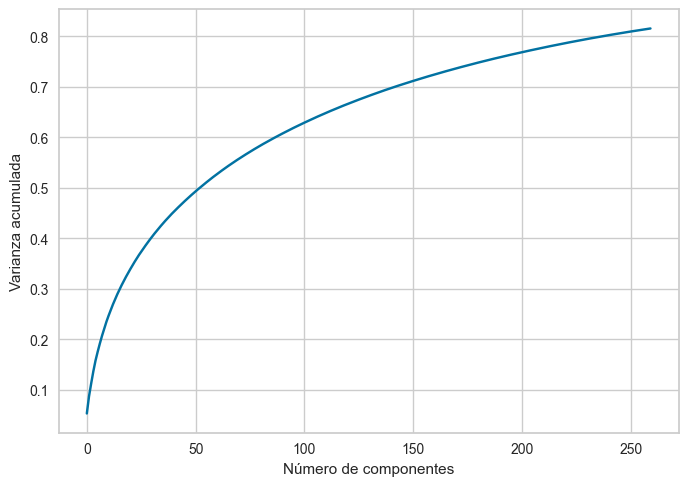

In [27]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")

plt.grid(True)
plt.show()

<h2 style="color:#7B3CC9; font-size: 1.2em; font-weight: bold;"> UMAP - 3 componentes </h2>

Se utilizan los componentes obtenidos de PCA para reducir dimensiones con UMAP a 3 componentes y así para poder obtener una visualización

In [28]:
%%time
umap_reducer = umap.UMAP(n_neighbors=15, n_components=3, random_state=42)
X_umap = umap_reducer.fit_transform(X_pca)  # reducción a 3D

C:\envs\spacy_env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


CPU times: total: 29.1 s
Wall time: 29.9 s


In [29]:
data_umap = pd.DataFrame(X_umap, columns=["UMAP1", "UMAP2", "UMAP3"], index=df.index)

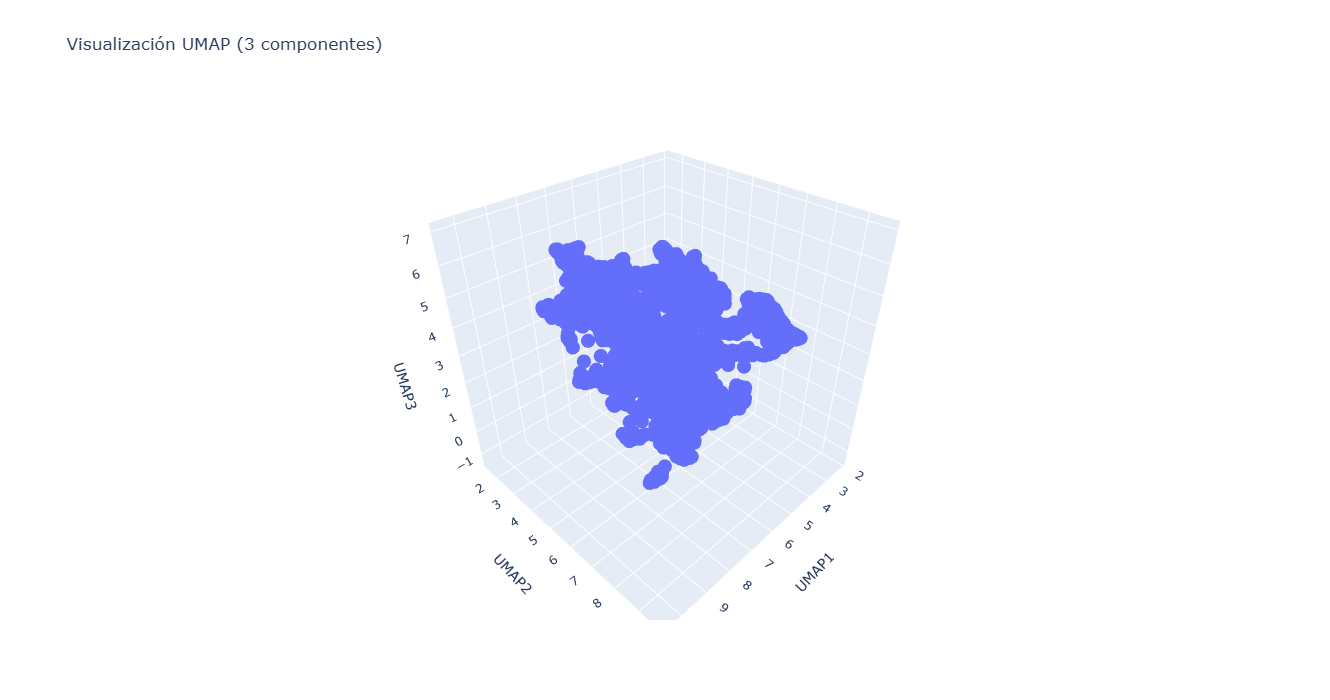

CPU times: total: 1.5 s
Wall time: 1.84 s


In [30]:
%%time
fig = px.scatter_3d(
    data_umap, x="UMAP1", y="UMAP2", z="UMAP3",
    title="Visualización UMAP (3 componentes)",
    width=900, height=700
)
fig.show()

<h2 style="background-color:#E3D5F5; color:#595959;">Paso 4: Clustering </h2> 

<h2 style="color:#7B3CC9; font-size: 1.2em; font-weight: bold;">  KMeans | GMM | DBSCAN - 160, 175 y 180, 190 Componentes </h2>

<p> Se realiza clustering con KMEANS,GMM y DBSCAN a distintos número de componetes para evaluar cuál es el que tiene mejores métricas. </p>
<p> Se decidió elegir KMEANS a 180 componentes de acuerdo con la siguiente tabla: </p>
<img src="../imgs/metricas_clustering_examen.png" alt="En verde podemos ver que a Kmenas le fue bien en todas las métricas" width="600" style="display: block; margin: 0 auto;">

In [31]:
%%time
results = []

for n in [160, 175, 180, 190]:
    # Reducción con UMAP
    umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=n, random_state=42)
    embedding = umap_model.fit_transform(X_pca)
    
    # --- KMeans ---
    kmeans = KMeans(n_clusters=5, random_state=42)
    labels_kmeans = kmeans.fit_predict(embedding)
    results.append({
        "n_components": n,
        "method": "KMeans",
        "Silhouette": silhouette_score(embedding, labels_kmeans),
        "Davies-Bouldin": davies_bouldin_score(embedding, labels_kmeans),
        "Calinski-Harabasz": calinski_harabasz_score(embedding, labels_kmeans)
    })
    
    # --- DBSCAN ---
    dbscan = DBSCAN(eps=0.5, min_samples=10)
    labels_dbscan = dbscan.fit_predict(embedding)
    if len(set(labels_dbscan)) > 1:  # evitar error si todo queda en un cluster
        results.append({
            "n_components": n,
            "method": "DBSCAN",
            "Silhouette": silhouette_score(embedding, labels_dbscan),
            "Davies-Bouldin": davies_bouldin_score(embedding, labels_dbscan),
            "Calinski-Harabasz": calinski_harabasz_score(embedding, labels_dbscan)
        })
    
    # --- GMM ---
    gmm = GaussianMixture(n_components=5, random_state=42)
    labels_gmm = gmm.fit_predict(embedding)
    results.append({
        "n_components": n,
        "method": "GMM",
        "Silhouette": silhouette_score(embedding, labels_gmm),
        "Davies-Bouldin": davies_bouldin_score(embedding, labels_gmm),
        "Calinski-Harabasz": calinski_harabasz_score(embedding, labels_gmm)
    })

# Resultados a DataFrame
results_df = pd.DataFrame(results)
print(results_df)

C:\envs\spacy_env\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

C:\envs\spacy_env\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

C:\envs\spacy_env\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

C:\envs\spacy_env\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



    n_components  method  Silhouette  Davies-Bouldin  Calinski-Harabasz
0            160  KMeans    0.327374        1.095250        2848.116139
1            160  DBSCAN   -0.252086        2.350982         148.064131
2            160     GMM    0.316777        1.146132        2756.978197
3            175  KMeans    0.360471        1.111432        3599.482462
4            175  DBSCAN   -0.267927        2.174447         147.856597
5            175     GMM    0.353427        1.134168        3548.048879
6            180  KMeans    0.321512        1.118032        2895.972948
7            180  DBSCAN   -0.206393        2.047081         177.305077
8            180     GMM    0.308769        1.175671        2754.398589
9            190  KMeans    0.320093        1.116157        2982.855096
10           190  DBSCAN   -0.275986        1.904169         133.343826
11           190     GMM    0.304014        1.161114        2757.069566
CPU times: total: 4min 18s
Wall time: 4min 19s


<h2 style="color:#7B3CC9; font-size: 1.2em; font-weight: bold;"> Silueta KMeans - 10 Clusters </h2>

<p> Se utiliza la silueta para evaluar la cantidad de clusters óptimos a utilizar. </p>
<p> S e ejecuta a 10 clusters solamente por tiempo de ejecución. </p>
<p> Podemos ver que la silueta nos dice que el número óptimo de clusters podría ser 2, es el que tiene la métrica más alta. </p>

N Clusters : 2
Score Silueta : 0.47


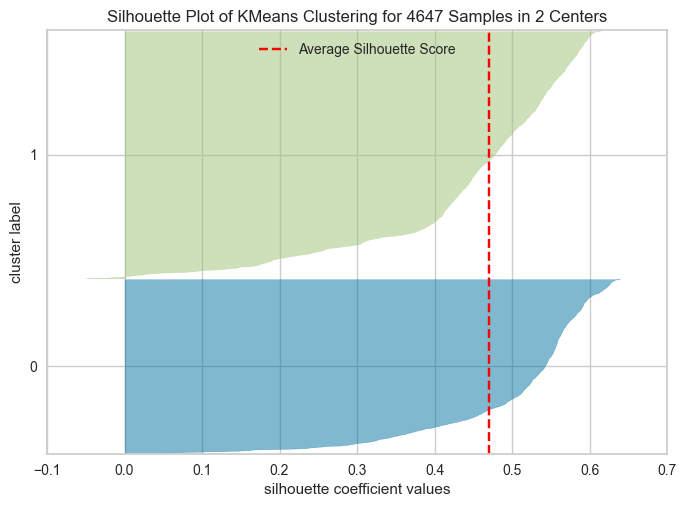

N Clusters : 3
Score Silueta : 0.4


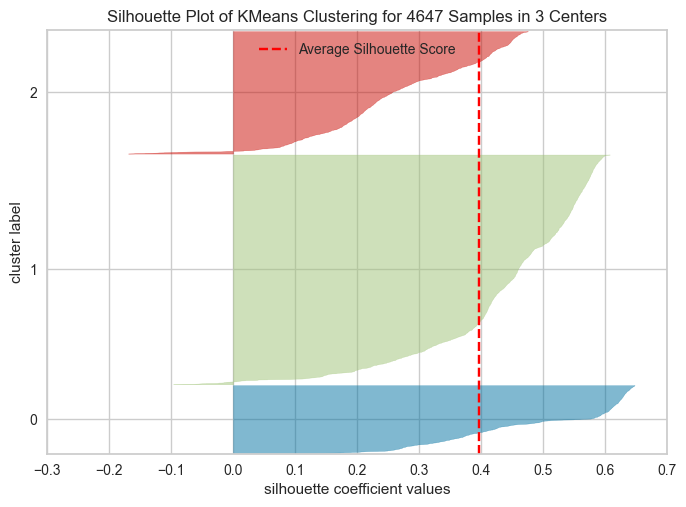

N Clusters : 4
Score Silueta : 0.3


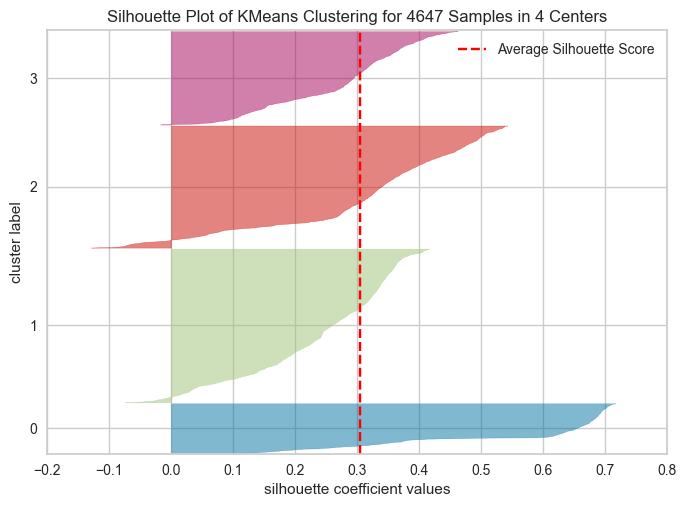

N Clusters : 5
Score Silueta : 0.36


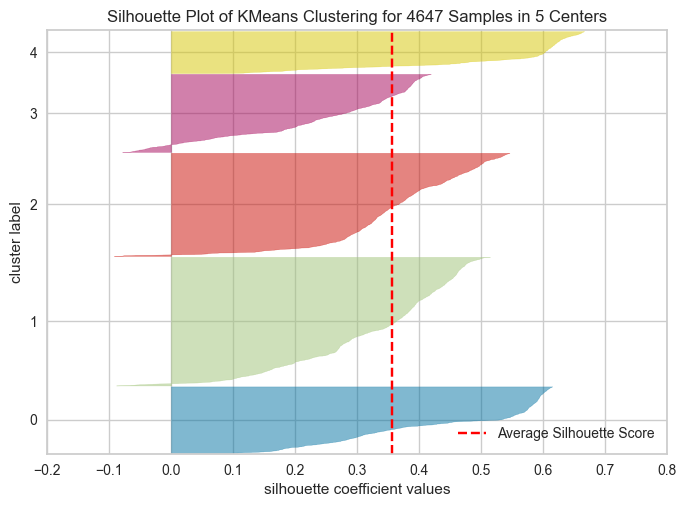

N Clusters : 6
Score Silueta : 0.34


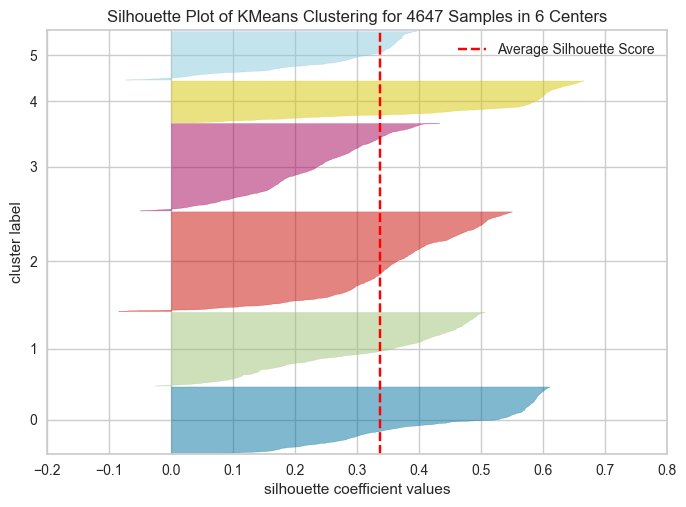

N Clusters : 7
Score Silueta : 0.36


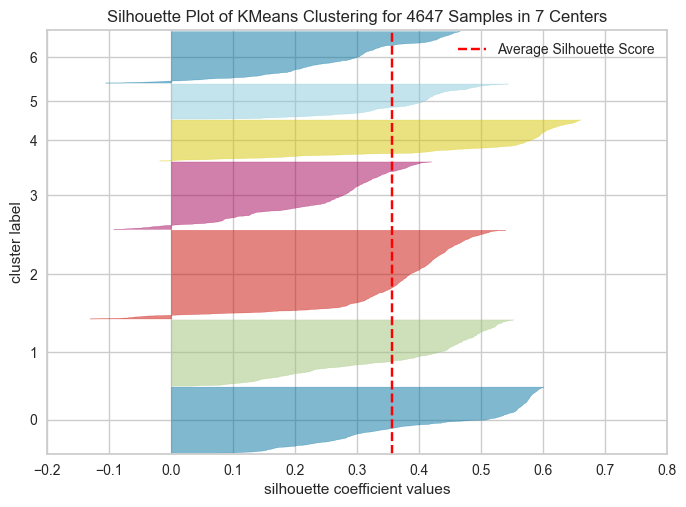

N Clusters : 8
Score Silueta : 0.34


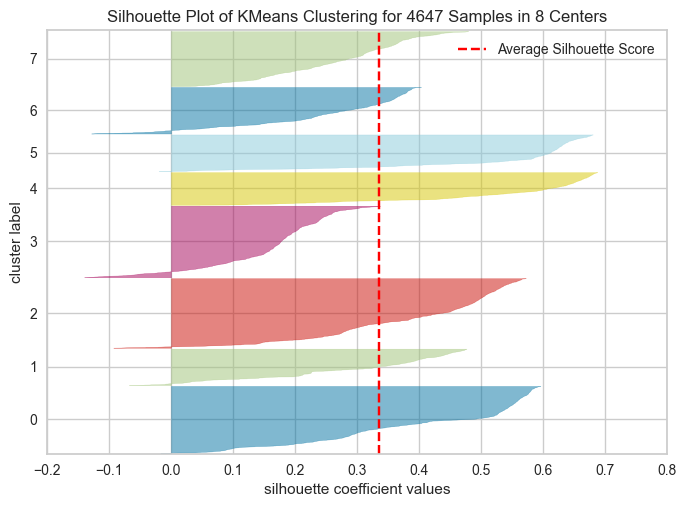

N Clusters : 9
Score Silueta : 0.36


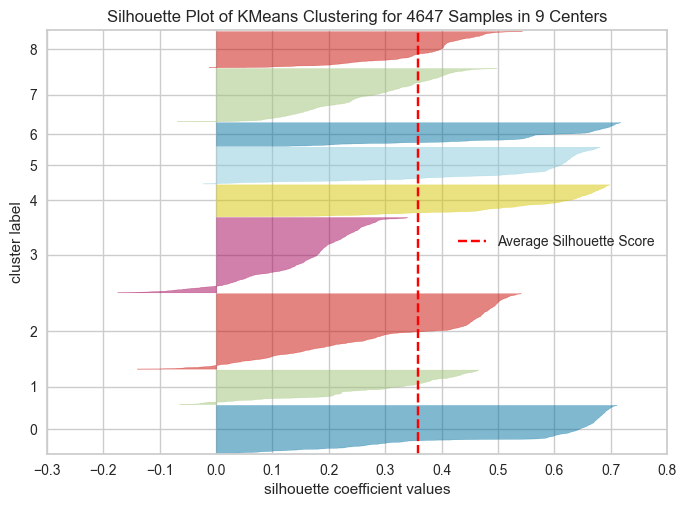

CPU times: total: 32.1 s
Wall time: 14.7 s


In [32]:
%%time
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=200)
    visualizer = SilhouetteVisualizer(km, colors='yellowbrick')
    visualizer.fit(embedding)  # Embeddings de UMAP
    print(f"N Clusters : {k}")
    print(f"Score Silueta : {round(visualizer.silhouette_score_, 2)}")
    visualizer.show()

<h2 style="color:#7B3CC9; font-size: 1.2em; font-weight: bold;"> Codo KMeans - 180 Componentes </h2>

<p> Se utiliza el codo para evaluar la cantidad de clusters óptimos a utilizar. </p>
<p> Podemos ver que el codo nos recomienda hacer 9 clusters. </p>
<p> Aquí se decidió usar 6 clusters, es donde yo noté la inflexión del codo, sin que fuera excesivo el número de clusters </p>

C:\envs\spacy_env\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



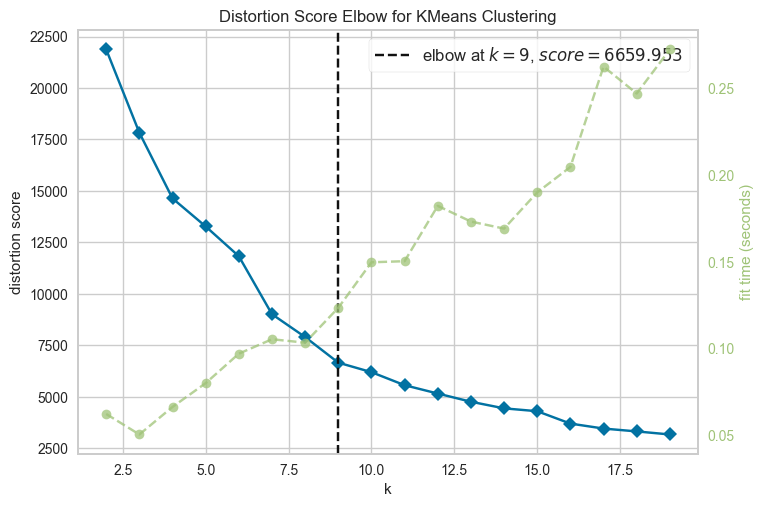

CPU times: total: 1min 17s
Wall time: 1min 9s


<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [33]:
%%time
# Reducción con UMAP a 180 componentes
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=180, random_state=42)
embedding_cluster = umap_model.fit_transform(X_pca)

# Función para graficar el codo
def codo(X, min_compo, max_compo):
    model = KMeans(random_state=42)
    visualizer = KElbowVisualizer(model, k=(min_compo, max_compo))
    visualizer.fit(X)
    return visualizer.show()

# Ejecución del codo
codo(embedding_cluster, 2, 20)

<h2 style="color:#7B3CC9; font-size: 1.2em; font-weight: bold;"> KMeans - Distribución de clusters </h2>

<p> Se visualiza en un diagrama de pastel como quedarían las distribuciones de las preguntas en cada cluster, parece que no hay desbalance </p>

In [79]:
X_pca_df = pd.DataFrame(X_pca, index=df.index)

In [80]:
KM_2 = KMeans(n_clusters=6, n_init=100, init='k-means++', random_state=42).fit(embedding_cluster)

In [81]:
X_pca_df["cluster_6"] = KM_2.labels_

In [82]:
%%time
# Contar elementos por cluster
pie = X_pca_df.groupby("cluster_6").size().reset_index()
pie.columns = ["cluster_6", "value"]

CPU times: total: 0 ns
Wall time: 541 μs


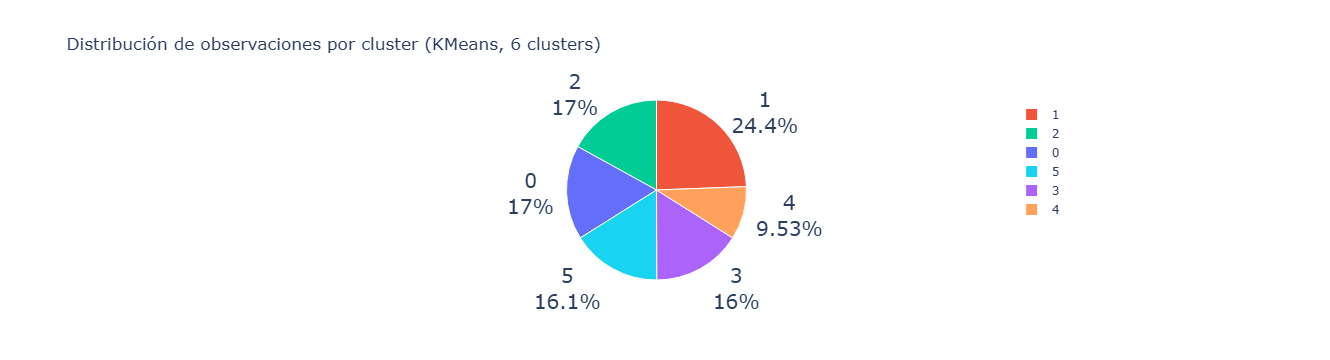

In [83]:
# Gráfico de pastel
fig = px.pie(
    pie,
    values='value',
    names='cluster_6',
    color='cluster_6',
    title="Distribución de observaciones por cluster (KMeans, 6 clusters)"
)

fig.update_traces(
    hoverinfo='label+percent',
    textinfo='percent+label',
    textfont_size=20,
    marker=dict(line=dict(color='white', width=1))
)

fig.update_layout(uniformtext_minsize=15, uniformtext_mode='hide')
fig.show()

<h2 style="color:#7B3CC9; font-size: 1.2em; font-weight: bold;"> KMeans - Visualización de clusters a 3 componentes </h2>

<p> Se obtiene visualización de clusterización con KMEANS con 6 clusters y 3 componentes </p>

In [77]:
%%time
# Reducción de dimensiones a 3 componentes
umap_vis3d = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=3, random_state=42)
embedding_3d = umap_vis3d.fit_transform(X_pca)

# KMeans con 2 clusters
KM_2 = KMeans(n_clusters=6, n_init=100, init='k-means++', random_state=42).fit(embedding_3d)
labels = KM_2.labels_

# Crear DataFrame con etiquetas
datos_vis = pd.DataFrame({
    "comp1": embedding_3d[:,0],
    "comp2": embedding_3d[:,1],
    "comp3": embedding_3d[:,2],
    "cluster": labels
})

C:\envs\spacy_env\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



CPU times: total: 20.3 s
Wall time: 15.7 s


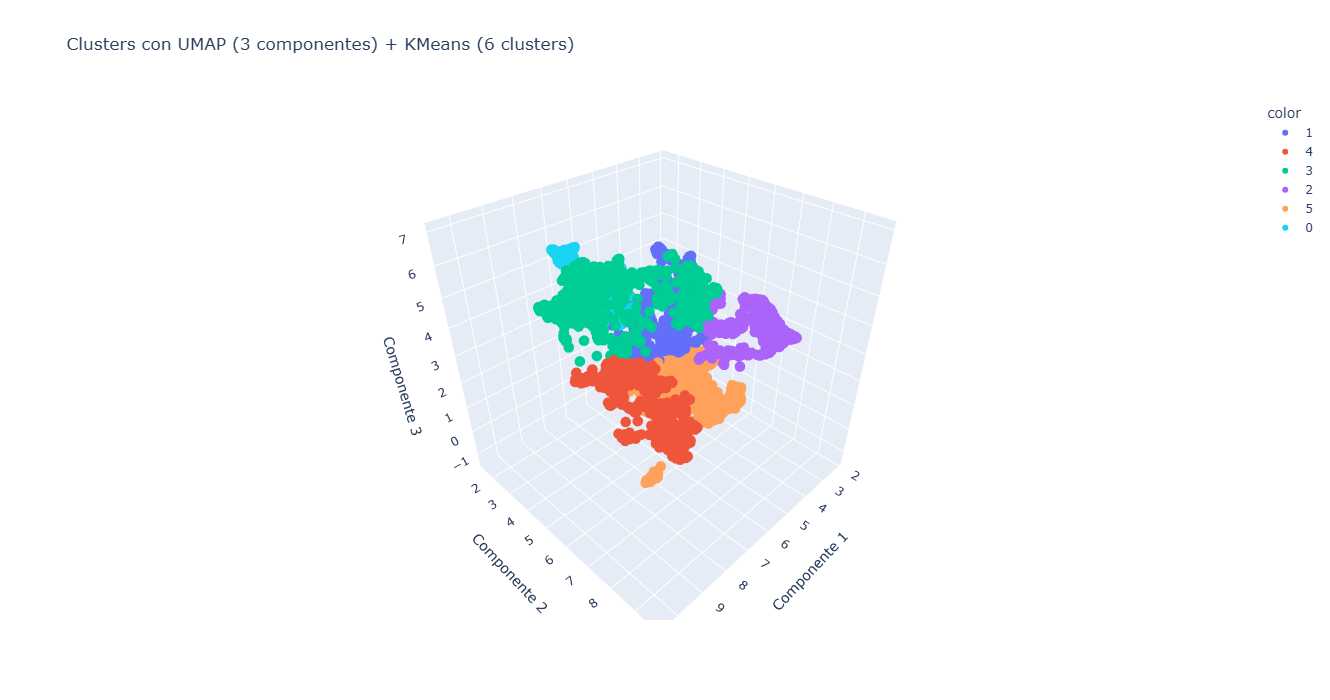

In [97]:
# Gráfico 3D
fig = px.scatter_3d(
    datos_vis, x="comp1", y="comp2", z="comp3",
    color=datos_vis["cluster"].astype(str),
    labels={"comp1": "Componente 1", "comp2": "Componente 2", "comp3": "Componente 3"},
    title="Clusters con UMAP (3 componentes) + KMeans (6 clusters)"
)

# Personalización de puntos
fig.update_traces(
    marker=dict(size=6, line=dict(width=0, color="Black")),
    selector=dict(mode="markers")
)

# Tamaño gráfico
fig.update_layout(
    width=900,
    height=700
)


fig.show()

<h2 style="background-color:#E3D5F5; color:#595959;">Paso 5: Perfilamiento </h2> 

<h2 style="color:#7B3CC9; font-size: 1.2em; font-weight: bold;"> Palabras más comúnes en el dataset </h2>

In [84]:
spanish_stopwords = stopwords.words("spanish")

In [85]:
vectorizer = CountVectorizer(stop_words=spanish_stopwords)
X_counts = vectorizer.fit_transform(df["pregunta_clean"])

In [86]:
# Palabras más frecuentes en todo el dataset
word_freq = dict(zip(vectorizer.get_feature_names_out(), X_counts.sum(axis=0).A1))
sorted(word_freq.items(), key=lambda x: x[1], reverse=True)[:20]

[('si', 606),
 ('tarjeta', 432),
 ('puedo', 377),
 ('prestamo', 325),
 ('nomina', 312),
 ('quiero', 283),
 ('cuenta', 275),
 ('gracias', 211),
 ('saber', 181),
 ('dinero', 169),
 ('ine', 150),
 ('credito', 140),
 ('datos', 127),
 ('numero', 124),
 ('necesito', 117),
 ('banco', 116),
 ('hola', 109),
 ('bien', 106),
 ('hacer', 98),
 ('ok', 94)]

<h2 style="color:#7B3CC9; font-size: 1.2em; font-weight: bold;"> Palabras más comúnes en cada cluster </h2>

In [87]:
df["cluster"] = labels

In [88]:
for c in df["cluster"].unique():
    palabras = " ".join(df[df["cluster"]==c]["pregunta_clean"]).split()
    # Filtrar stopwords
    palabras_filtradas = [p for p in palabras if p.lower() not in spanish_stopwords]
    top_palabras = Counter(palabras_filtradas).most_common(10)
    print(f"Cluster {c}: {top_palabras}")

Cluster 1: [('ine', 136), ('datos', 115), ('si', 92), ('puedo', 79), ('foto', 38), ('hacer', 34), ('aser', 31), ('credencial', 29), ('q', 28), ('bien', 24)]
Cluster 4: [('prestamo', 298), ('si', 132), ('dinero', 130), ('puedo', 102), ('quiero', 81), ('saber', 62), ('credito', 61), ('cuanto', 60), ('necesito', 51), ('retirar', 37)]
Cluster 3: [('tarjeta', 417), ('nomina', 294), ('si', 128), ('cuenta', 116), ('quiero', 106), ('puedo', 103), ('banco', 100), ('credito', 76), ('saber', 56), ('bancomer', 39)]
Cluster 2: [('nombre', 33), ('jose', 31), ('si', 25), ('fecha', 23), ('nacimiento', 22), ('trabajo', 16), ('hernandez', 16), ('edad', 15), ('naci', 15), ('hola', 14)]
Cluster 5: [('si', 195), ('gracias', 158), ('bien', 55), ('ok', 52), ('quiero', 50), ('mas', 42), ('saber', 40), ('hola', 33), ('ayuda', 30), ('muchas', 29)]
Cluster 0: [('cuenta', 139), ('numero', 84), ('correo', 83), ('puedo', 53), ('electronico', 38), ('abrir', 35), ('si', 34), ('quiero', 32), ('aplicacion', 25), ('app'

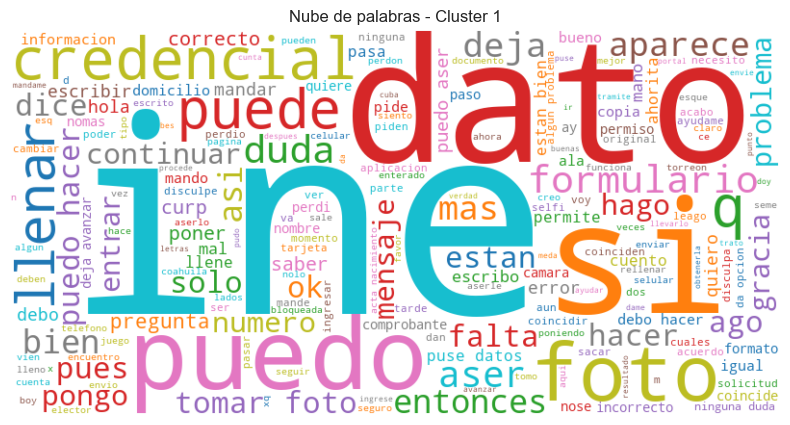

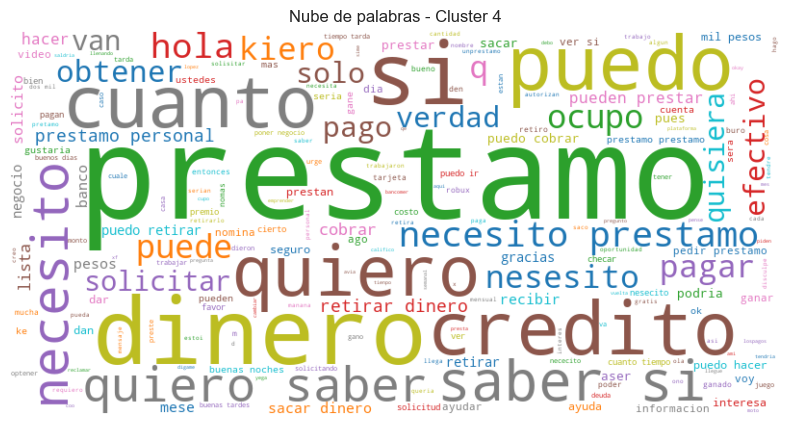

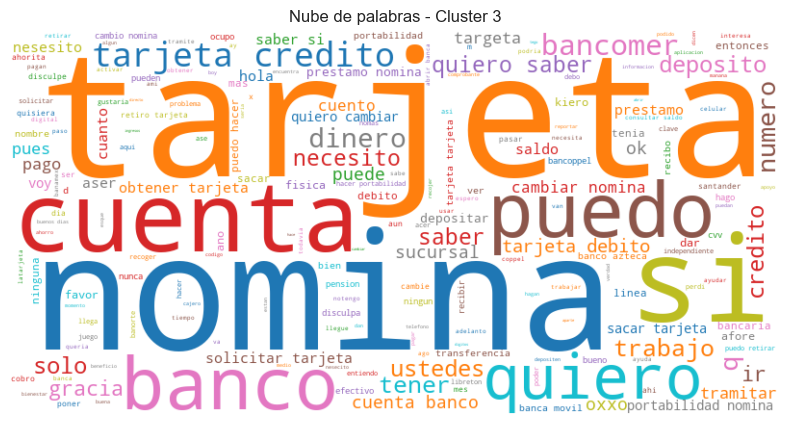

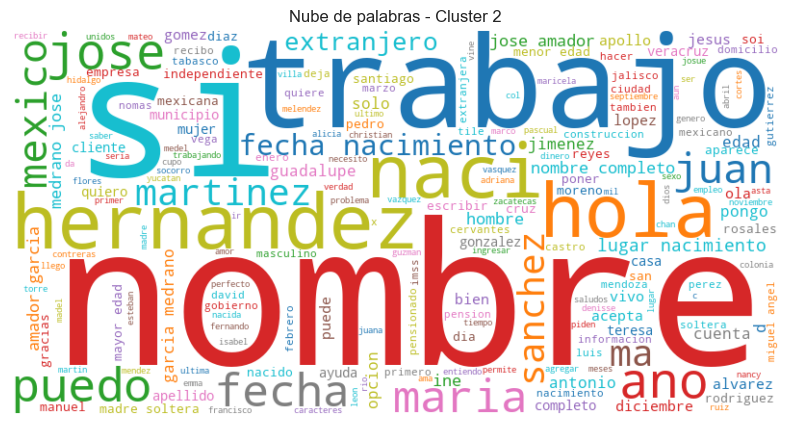

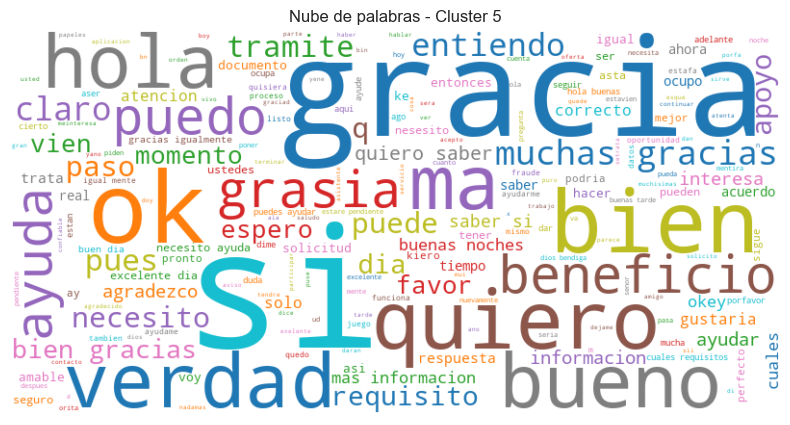

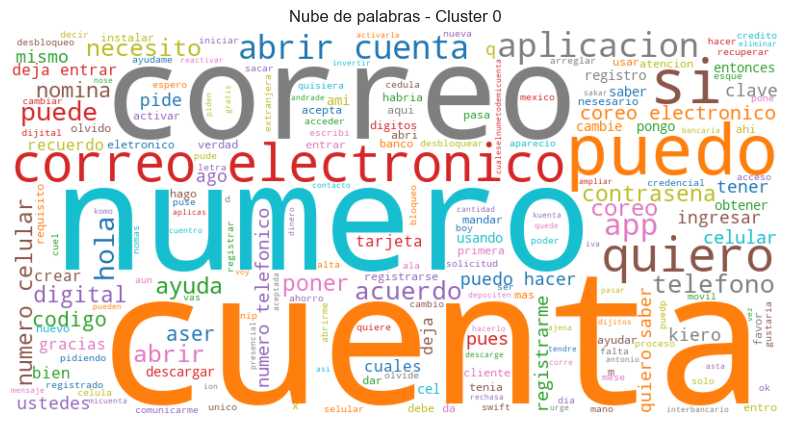

In [89]:
for c in df["cluster"].unique():
    # Concatenar todas las preguntas del cluster
    textos = " ".join(df[df["cluster"]==c]["pregunta_clean"])
    
    # Filtrar stopwords
    palabras_filtradas = " ".join(
        [p for p in textos.split() if p.lower() not in spanish_stopwords]
    )
    
    # Nube de palabras
    wordcloud = WordCloud(
        width=800, height=400,
        background_color="white",
        colormap="tab10"
    ).generate(palabras_filtradas)
    
    # Mostrar
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Nube de palabras - Cluster {c}")
    plt.show()

<h2 style="color:#7B3CC9; font-size: 1.2em; font-weight: bold;"> preguntas más comúnes en cada cluster </h2>

In [96]:
# Seleccionar 8 preguntas de cada cluster
ejemplos_por_cluster = (
    df.groupby("cluster")
    .apply(lambda x: x["pregunta_clean"].head(8))
)

# Mostrar resultados
print(ejemplos_por_cluster)

cluster    
0        29                      no puedo entrar no se mi correo
         48                             pero necesito una cuenta
         54    si m solicitud es aceptada tengo q dar un nume...
         55                                   correo electronico
         76                            ya aparecio la cantidad $
         77                                       cuales digitos
         83                              no en cuentro mi correo
         85                                      no tengo la app
1        0                            por que no puedo continuar
         5            en una secuencia de aporte de datos segura
         12                              si estan bien los datos
         16                          cual es el numero de mi ine
         19                                 estan bien mis datos
         24            como resibire el formulario para llenarlo
         26                                 pero no la tengo aun
         32  

C:\Users\erika\AppData\Local\Temp\ipykernel_18588\2745681343.py:4: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



<h2 style="color:#7B3CC9; font-size: 1.2em; font-weight: bold;"> Perfilamiento final </h2>

| Cluster | Nombre corto | Descripción |
|----------|----------|----------|
| 0    | Banca digital   | **Preguntas relacionadas con el uso de la aplicación bancaria:** problemas para ingresar, recuperación de contraseñas, registro de cuentas digitales y uso de tarjetas digitales. Refleja dudas sobre la experiencia de acceso y autenticación en canales digitales.   |
| 1    | Documentación de identidad   | **Consultas sobre requisitos de identificación:** uso de INE, envío de fotos, llenado de formularios. Representa inquietudes sobre validación de identidad y procesos de onboarding digital.   |
| 2    | Créditos   | **Preguntas sobre productos crediticios:** préstamos personales, pagos de créditos. Agrupa dudas sobre productos de crédito y su gestión.   |
| 3    | Cuentas de nómina y portabilidad   | **Consultas sobre cuentas de nómina**, tarjetas de débito asociadas, depósitos y portabilidad de nómina. Refleja necesidades de cuentas donde se reflejan ingresos laborales.   |
| 4    | Registro   | **Preguntas sobre el proceso de registro:** nombre, apellidos, fecha de nacimiento, municipio, edad. Agrupa inquietudes sobre el alta de clientes y captura de datos personales en el sistema bancario.  |
| 5    | Requisitos y servicios complementarios   | **Dudas sobre documentación adicional**, requisitos específicos y localización de servicios. Este cluster refleja consultas que fueron atendidas satisfactoriamente, relacionadas con trámites y servicios complementarios.   |